# Statistical Baseline: ARIMA for Short-Term Energy Forecasting

In [12]:
import importlib.util
import os
import random
import subprocess
import sys
import warnings

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "statsmodels": "statsmodels",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib"
}

for module_name, package_name in required_packages.items():
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

np.random.seed(42)
random.seed(42)

In [13]:
candidate_paths = [
    "/kaggle/input/total-consumption-data/total_consumption_data.csv",
    "/kaggle/input/datasets/rahulsarav/total-consumption-data/total_consumption_data.csv",
    "/kaggle/input/total_consumption_data.csv",
    "total_consumption_data.csv"
]

data_path = None
for p in candidate_paths:
    if os.path.exists(p):
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError("total_consumption_data.csv was not found in expected Kaggle/local paths")

df = pd.read_csv(data_path)
df.columns = [c.strip() for c in df.columns]

if np.issubdtype(df["datetime"].dtype, np.number):
    df["datetime"] = pd.to_datetime(df["datetime"], unit="s", errors="coerce")
else:
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

for col in df.columns:
    if col not in ["datetime", "meter_id"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

target_col = "apower_ph1" if "apower_ph1" in df.columns else "apower"
df = df.dropna(subset=["datetime", "meter_id", target_col]).copy()
df = df.sort_values(["meter_id", "datetime"]).reset_index(drop=True)

# 30-minute bins, per meter
df["bin30"] = df["datetime"].dt.floor("30min")
panel = df.groupby(["meter_id", "bin30"], as_index=False)[target_col].mean()

meter_rank = panel.groupby("meter_id").size().sort_values(ascending=False)
N_METERS = 10
selected_meters = meter_rank.head(N_METERS).index.tolist()
panel = panel[panel["meter_id"].isin(selected_meters)].copy()
panel = panel.sort_values(["meter_id", "bin30"]).reset_index(drop=True)

print("Data path:", data_path)
print("Target column:", target_col)
print("Bin frequency: 30 min")
print("Meters selected:", len(selected_meters), "->", selected_meters)
print("Total rows:", len(panel))
panel.head()

Data path: /kaggle/input/datasets/rahulsarav/total-consumption-data/total_consumption_data.csv
Target column: apower_ph1
Bin frequency: 30 min
Meters selected: 6 -> ['00124B0018D7080C', '00124B0018D6F755', '00124B0018D6F607', '00124B0018D6F74C', '00124B0018D6F752', '00124B0018D6FB1E']
Total rows: 4805


,meter_id,bin30,apower_ph1
0,00124B0018D6F607,2019-08-27 22:00:00,486.233333
1,00124B0018D6F607,2019-08-27 22:30:00,405.133333
2,00124B0018D6F607,2019-08-27 23:00:00,526.766667
3,00124B0018D6F607,2019-08-27 23:30:00,767.233333
4,00124B0018D6F607,2019-08-28 00:00:00,657.900000


In [14]:
def pick_d(series_in, max_d=2, alpha=0.05):
    pvals = {}
    for d in range(max_d + 1):
        s = series_in.diff(d).dropna() if d > 0 else series_in.dropna()
        if len(s) < 30:
            continue
        p = adfuller(s, autolag="AIC")[1]
        pvals[d] = float(p)
        if p < alpha:
            return d, pvals
    if len(pvals) == 0:
        return 0, pvals
    return min(pvals, key=pvals.get), pvals

def metric_row(name, y_true, y_pred):
    yt = np.asarray(y_true).reshape(-1)
    yp = np.asarray(y_pred).reshape(-1)
    return {
        "Model":     name,
        "MAE":       float(mean_absolute_error(yt, yp)),
        "RMSE":      float(np.sqrt(mean_squared_error(yt, yp))),
        "R2":        float(r2_score(yt, yp)),
        "MAPE(%)":   float(np.mean(np.abs((yt - yp) / (np.abs(yt) + 1e-6))) * 100.0)
    }

all_metrics = []
all_preds   = []

for meter_id, g in panel.groupby("meter_id"):
    g = g.sort_values("bin30").reset_index(drop=True)

    # Reindex onto a clean 30-min grid to fill any gaps
    full_idx = pd.date_range(g["bin30"].iloc[0], g["bin30"].iloc[-1], freq="30min")
    series = (
        g.set_index("bin30")[target_col]
        .astype(float)
        .reindex(full_idx)
        .interpolate(method="time", limit=4)
        .dropna()
    )

    n = len(series)
    if n < 48:
        print(f"Skipping meter {meter_id}: only {n} points after reindex")
        continue

    train_end = int(n * 0.70)
    val_end   = int(n * 0.85)
    train = series.iloc[:train_end]
    val   = series.iloc[train_end:val_end]
    test  = series.iloc[val_end:]

    d_order, _ = pick_d(train, max_d=2, alpha=0.05)

    orders = [(p, d_order, q) for p in range(0, 4) for q in range(0, 4)]
    orders = random.sample(orders, k=min(16, len(orders)))

    best_order, best_val_rmse = None, np.inf
    for order in orders:
        try:
            m = ARIMA(train, order=order,
                      enforce_stationarity=False,
                      enforce_invertibility=False).fit()
            pred_val = m.forecast(steps=len(val))
            val_rmse = float(np.sqrt(mean_squared_error(val.values, pred_val.values)))
            if val_rmse < best_val_rmse:
                best_val_rmse = val_rmse
                best_order    = order
        except Exception:
            pass

    if best_order is None:
        best_order = (1, d_order, 1)

    train_val    = pd.concat([train, val])
    final_model  = ARIMA(train_val, order=best_order,
                         enforce_stationarity=False,
                         enforce_invertibility=False).fit()

    # Rolling one-step-ahead forecast — update state with true obs each step
    result       = final_model
    rolling_preds = []
    for obs in test.values:
        yhat = float(result.forecast(steps=1).iloc[0])
        rolling_preds.append(yhat)
        result = result.append([obs], refit=False)

    pred_test = pd.Series(rolling_preds, index=test.index)

    row = metric_row("ARIMA", test.values, pred_test.values)
    row["meter_id"]   = meter_id
    row["best_order"] = str(best_order)
    all_metrics.append(row)

    pf = pd.DataFrame({
        "meter_id":   meter_id,
        "datetime":   test.index,
        "actual":     test.values,
        "pred_arima": pred_test.values
    })
    all_preds.append(pf)
    print(f"Meter {meter_id} | order={best_order} | test RMSE={row['RMSE']:.4f}")

metrics_df = pd.DataFrame(all_metrics)
preds_df   = pd.concat(all_preds, ignore_index=True)

print("\n--- Per-meter summary ---")
display(metrics_df.round(4))
print("\n--- Aggregate (mean across meters) ---")
display(metrics_df[["MAE","RMSE","R2","MAPE(%)"]].mean().round(4))

metrics_df.to_csv("paper_arima_metrics.csv", index=False)
preds_df.to_csv("paper_arima_predictions.csv", index=False)
print("Saved: paper_arima_metrics.csv, paper_arima_predictions.csv")

Meter 00124B0018D6F607 | order=(0, 0, 1) | test RMSE=437.9561
Meter 00124B0018D6F74C | order=(3, 0, 2) | test RMSE=396.3560
Meter 00124B0018D6F752 | order=(3, 0, 2) | test RMSE=498.6844
Meter 00124B0018D6F755 | order=(0, 0, 3) | test RMSE=461.0684
Meter 00124B0018D6FB1E | order=(3, 0, 2) | test RMSE=408.4921
Meter 00124B0018D7080C | order=(2, 0, 3) | test RMSE=295.1586

--- Per-meter summary ---


,Model,MAE,RMSE,R2,MAPE(%),meter_id,best_order
0,ARIMA,384.8137,437.9561,-0.3073,336.8684,00124B0018D6F607,"(0, 0, 1)"
1,ARIMA,310.7370,396.3560,-0.2570,307.9127,00124B0018D6F74C,"(3, 0, 2)"
2,ARIMA,454.5505,498.6844,-0.2547,191.0204,00124B0018D6F752,"(3, 0, 2)"
3,ARIMA,358.9942,461.0684,0.1431,108.8950,00124B0018D6F755,"(0, 0, 3)"
4,ARIMA,354.5643,408.4921,-0.0221,147.4538,00124B0018D6FB1E,"(3, 0, 2)"
5,ARIMA,237.2482,295.1586,-0.1861,435.9334,00124B0018D7080C,"(2, 0, 3)"



--- Aggregate (mean across meters) ---


MAE        350.1513
RMSE       416.2860
R2          -0.1473
MAPE(%)    254.6806
dtype: float64

Saved: paper_arima_metrics.csv, paper_arima_predictions.csv


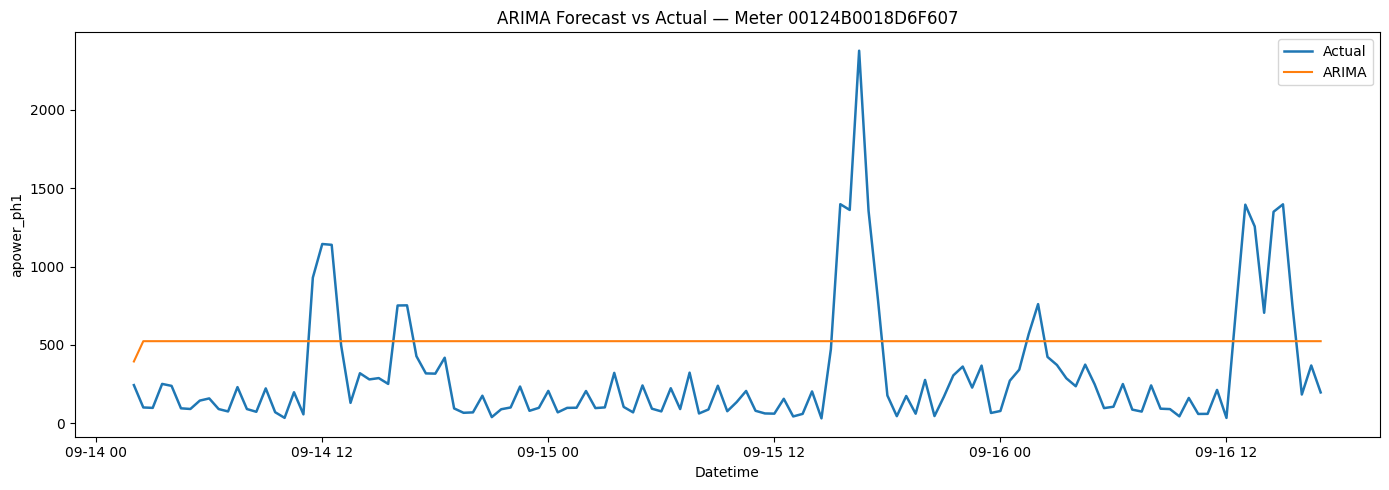

In [15]:
plot_df = all_preds[0]
plot_n  = min(96, len(plot_df))   # 2 days of 30-min bins
mid     = plot_df["meter_id"].iloc[0]

plt.figure(figsize=(14, 5))
plt.plot(plot_df["datetime"].iloc[:plot_n], plot_df["actual"].iloc[:plot_n],
         label="Actual", linewidth=1.8)
plt.plot(plot_df["datetime"].iloc[:plot_n], plot_df["pred_arima"].iloc[:plot_n],
         label="ARIMA", linewidth=1.5)
plt.title(f"ARIMA Forecast vs Actual — Meter {mid}")
plt.xlabel("Datetime")
plt.ylabel(target_col)
plt.legend()
plt.tight_layout()
plt.show()